In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

In [2]:
Data =pd.read_csv('Pharma_Industry.csv')
Data.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
Data.shape

(500, 6)

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
Data.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


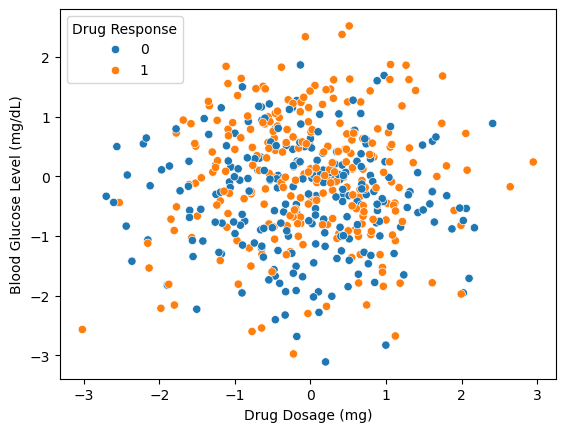

In [6]:
sns.scatterplot(x="Drug Dosage (mg)",y="Blood Glucose Level (mg/dL)",hue="Drug Response",data=Data)
plt.show()

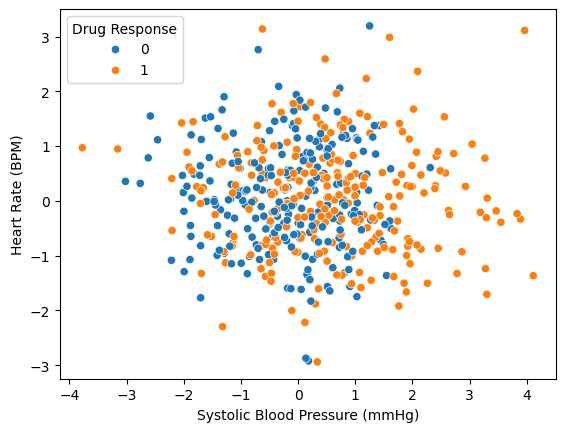

In [7]:
sns.scatterplot(x="Systolic Blood Pressure (mmHg)",y="Heart Rate (BPM)",hue="Drug Response",data=Data)
plt.show()

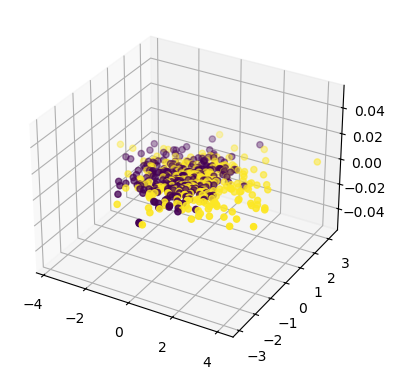

In [8]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(222,projection='3d')
ax.scatter(Data["Systolic Blood Pressure (mmHg)"],Data["Heart Rate (BPM)"],c=Data["Drug Response"],cmap="viridis")
plt.show()

In [9]:
## checking null values
Data.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [10]:
## checking Duplicated values
Data.duplicated().sum()

np.int64(0)

<Axes: >

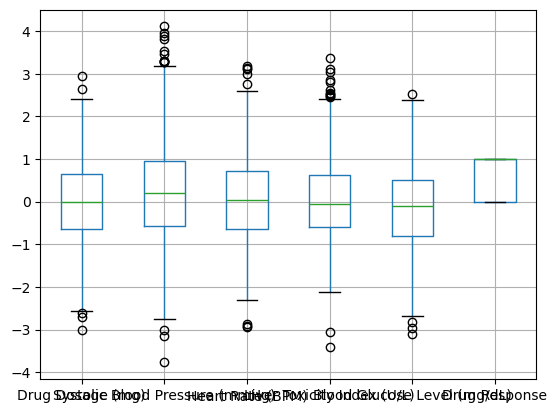

In [11]:
Data.boxplot()

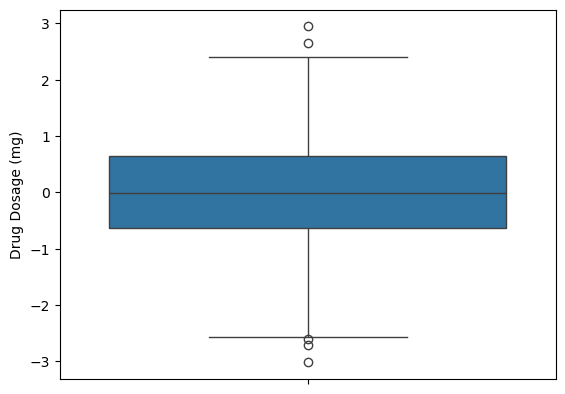

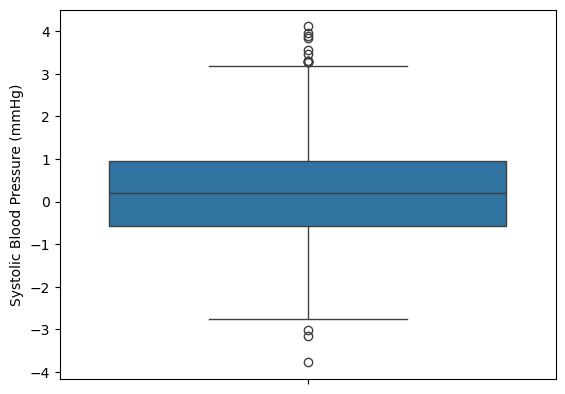

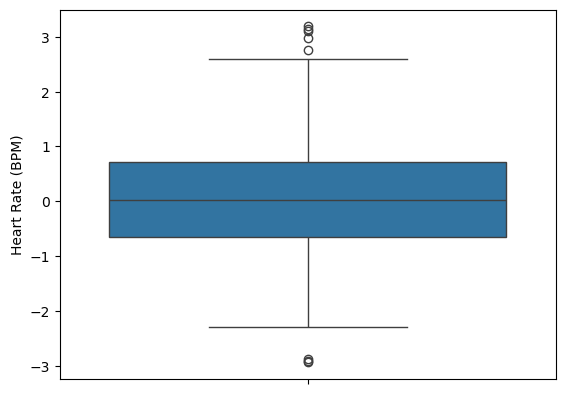

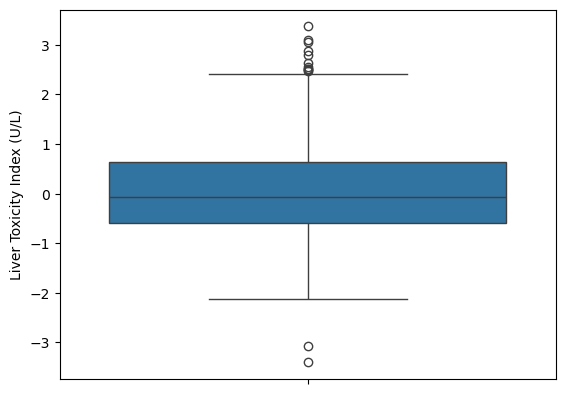

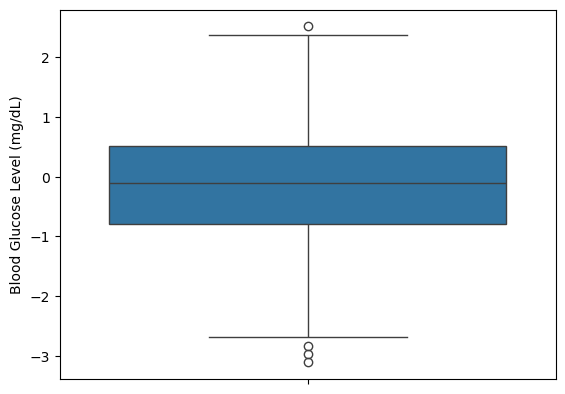

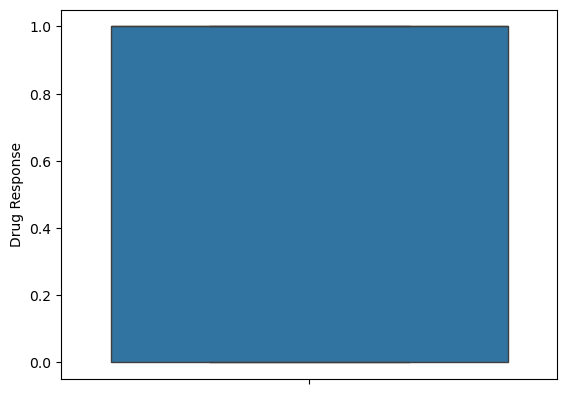

In [12]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [13]:
### outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in Data.select_dtypes(include=['int','float']).columns:
    outlier_capping(Data,col)

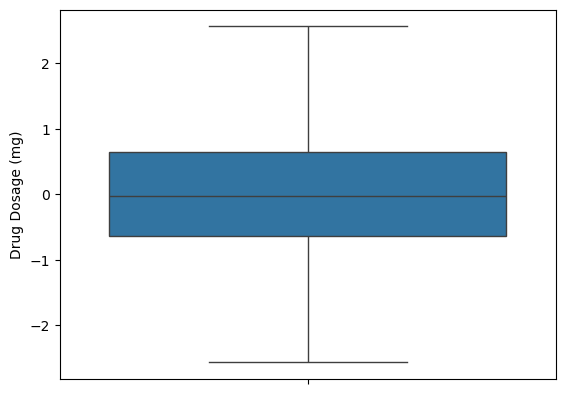

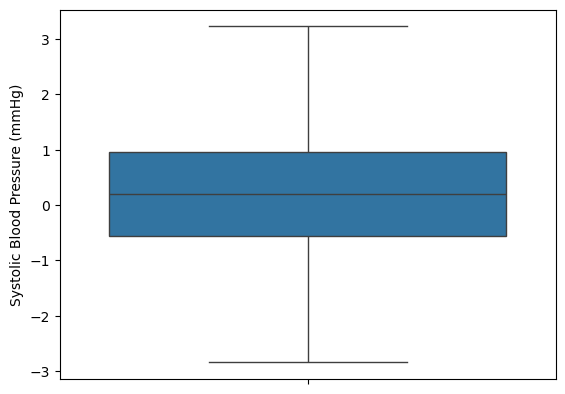

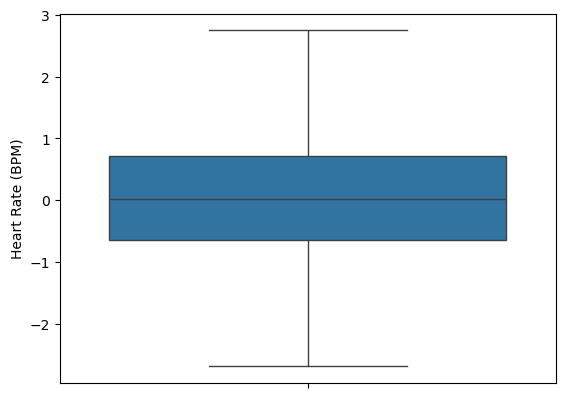

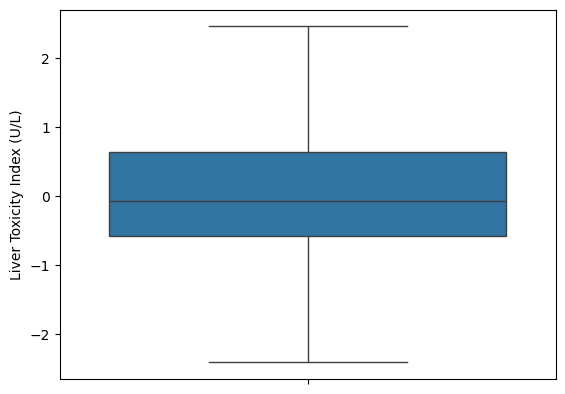

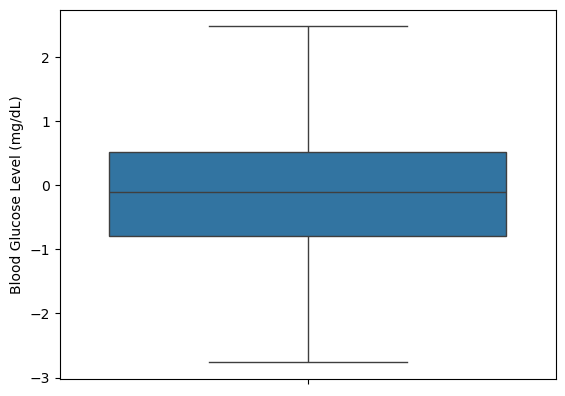

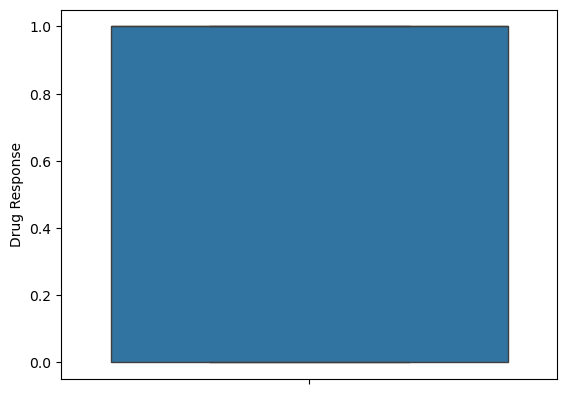

In [14]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

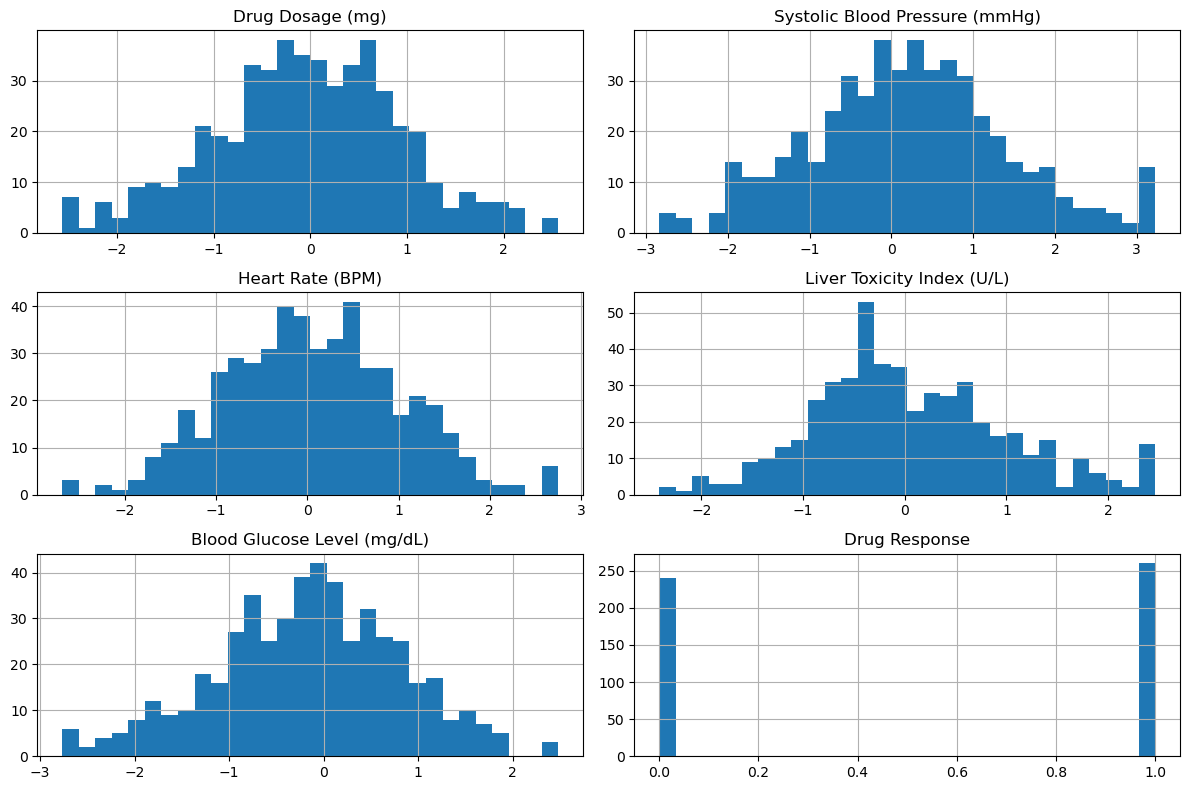

In [15]:
Data.hist(figsize=(12,8),bins=30)
plt.tight_layout()
plt.show()

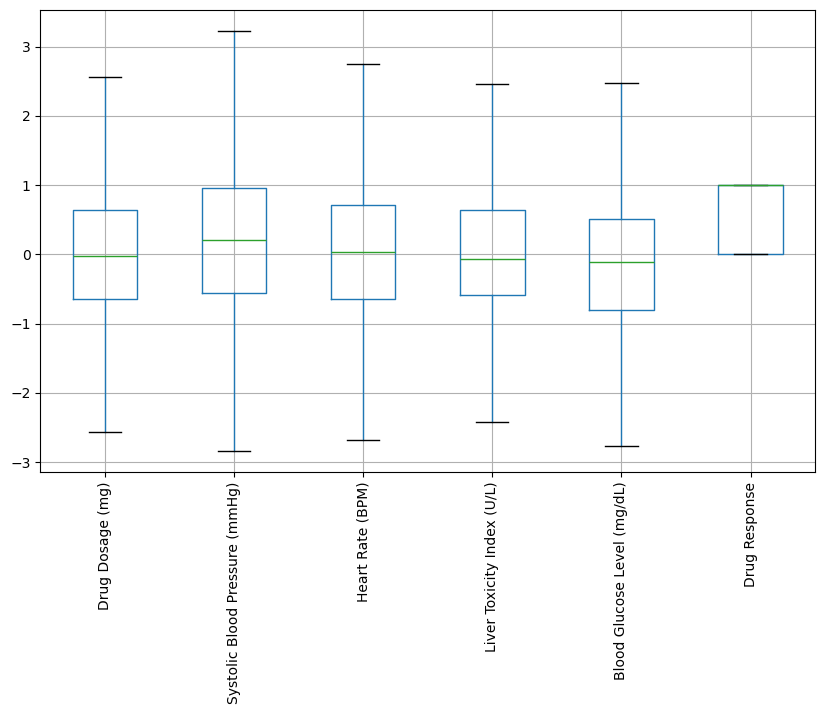

In [16]:
plt.figure(figsize=(10, 6))
Data.boxplot()
plt.xticks(rotation=90)
plt.show()

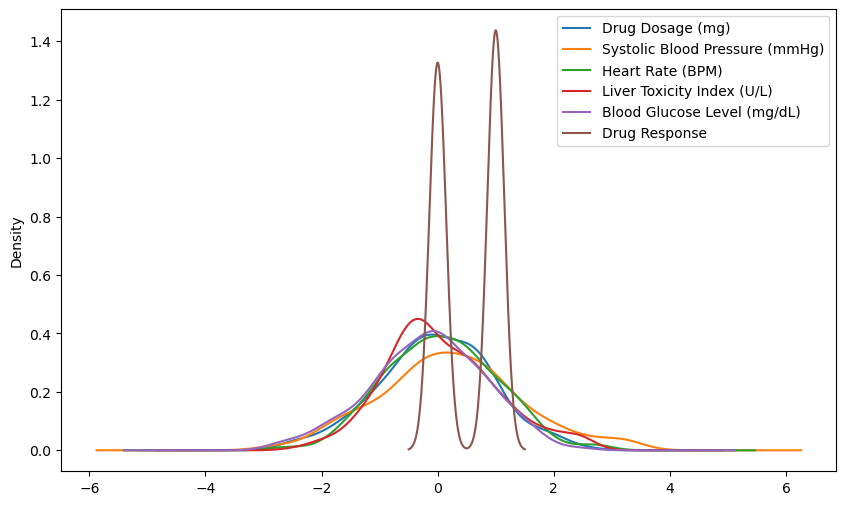

In [17]:
Data.plot(kind='density', figsize=(10, 6))
plt.show()

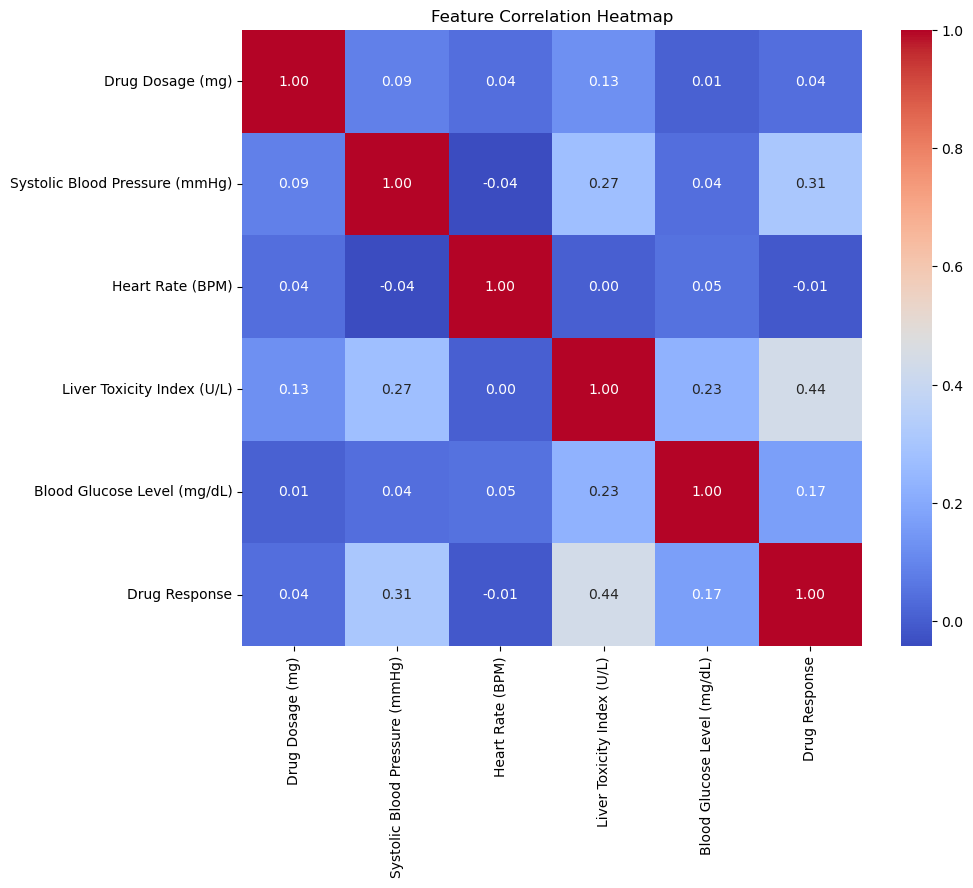

In [18]:
## plotting correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(Data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
Data["Drug Response"].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

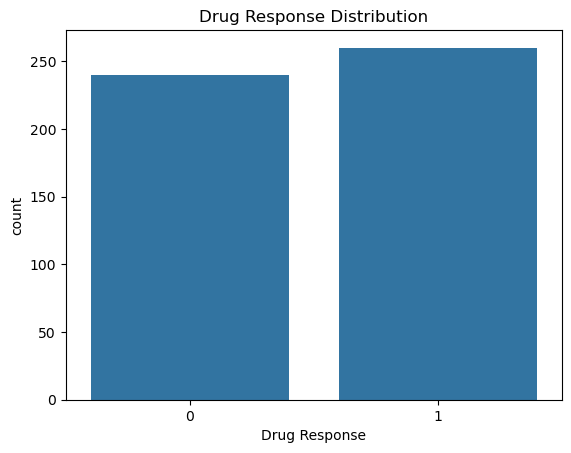

In [20]:
sns.countplot(x="Drug Response",data=Data)
plt.title("Drug Response Distribution")
plt.show()

In [21]:
## The dataset contains only numerical features; therefore, no categorical encoding techniques such as Label Encoding or One-Hot Encoding were required.

In [22]:
features=Data.drop(columns=['Drug Response'])
target=Data['Drug Response']

In [23]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [24]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


In [25]:
std_sca=StandardScaler()

In [26]:
x_train = std_sca.fit_transform(x_train)
x_test = std_sca.transform(x_test)

In [27]:
x_train= pd.DataFrame(x_train)
x_train

,0,1,2,3,4
0,0.397411,0.083329,0.137003,0.035213,0.199889
1,0.951421,-0.031350,-1.484074,-0.382894,-0.606179
2,2.175103,-0.513256,-1.190296,0.502114,-0.360403
3,-1.768241,0.204605,0.367168,0.742207,0.926309
4,-0.322952,1.666862,0.087298,0.103526,0.601173
...,...,...,...,...,...
395,0.627033,0.994148,-1.033254,1.429266,0.332260
396,-2.580275,0.571745,0.651214,-0.904696,-0.152861
397,-0.587405,2.096709,0.845892,1.819434,1.722208
398,-0.615509,0.026285,-1.995412,0.350399,0.513127


In [28]:
x_test= pd.DataFrame(x_test)
x_test

,0,1,2,3,4
0,-0.607447,-0.229599,1.809074,0.138119,-2.398941
1,0.620224,0.795805,-0.332979,0.762105,0.806622
2,-0.439835,-0.504918,0.090890,2.178553,-0.677446
3,0.056599,-1.487889,-0.073797,-0.510304,0.831455
4,1.301348,1.496581,0.211650,-0.893267,1.387878
...,...,...,...,...,...
95,-0.884766,0.539474,-0.941607,-1.175760,1.857031
96,1.187340,0.396389,2.002188,-0.426075,-0.306628
97,2.086673,0.266592,-1.714353,-1.262776,-0.353675
98,1.775430,0.489402,1.350281,0.369259,0.185772


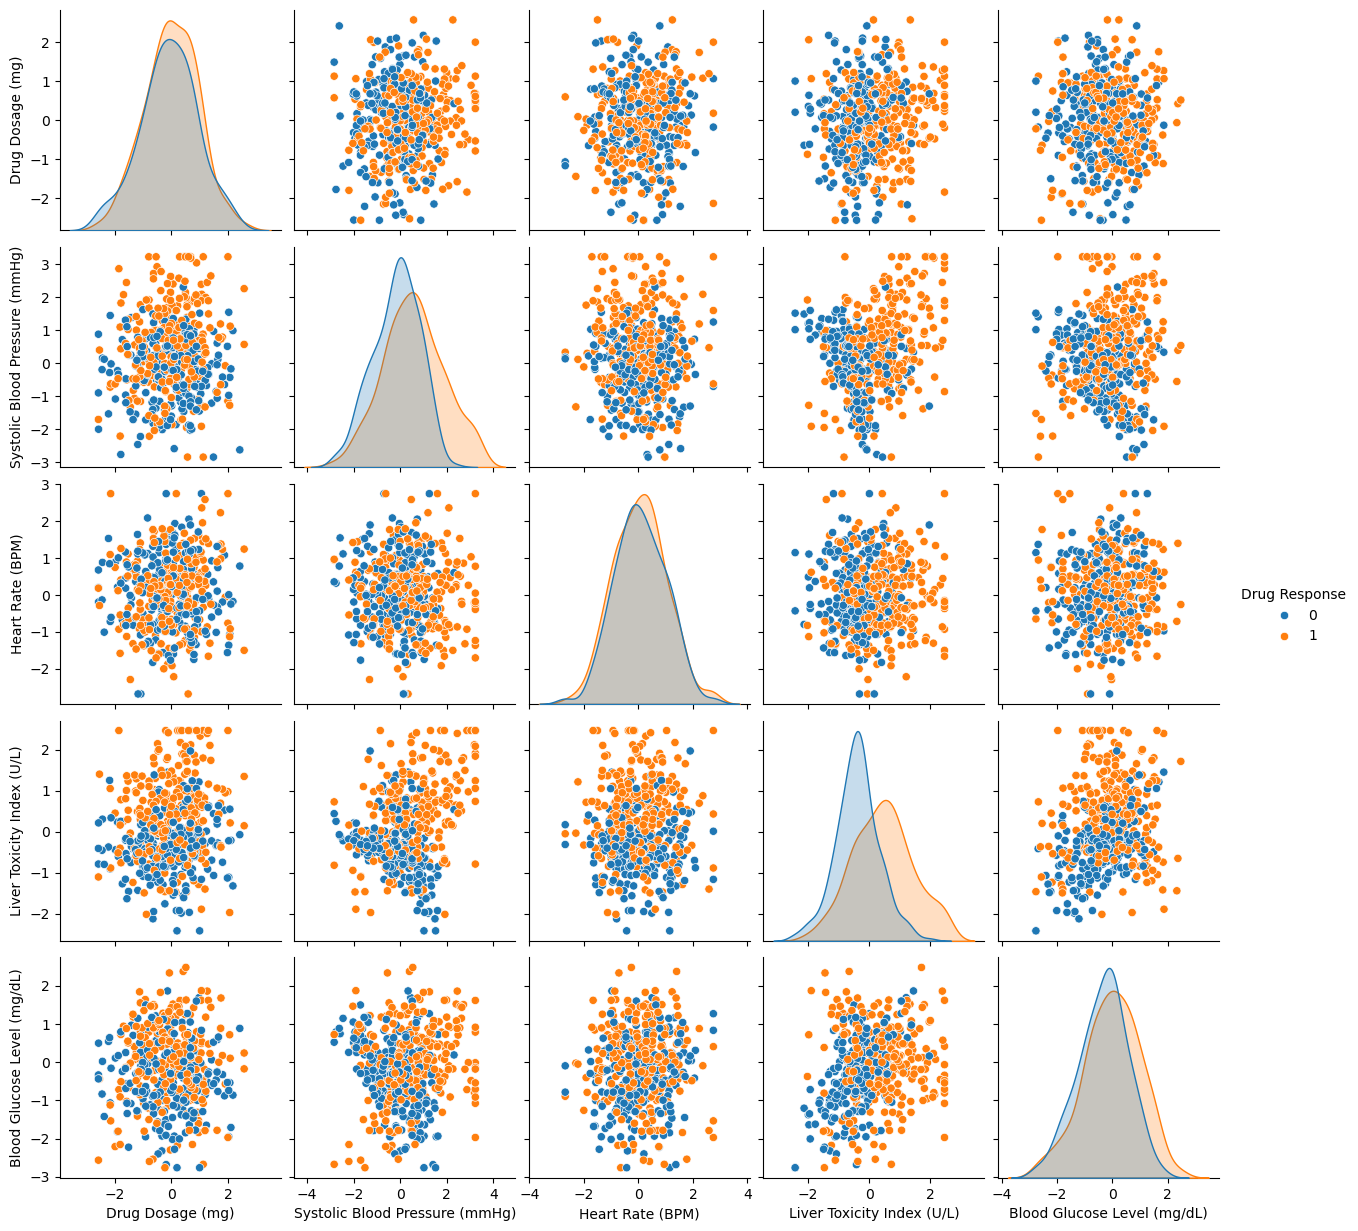

In [29]:
sns.pairplot(Data,hue="Drug Response",diag_kind="kde")
plt.show()

In [30]:
## Linear karnel

In [31]:
svc= SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

In [32]:
print("acc:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("reacall:", recall_score(y_test,y_pred))
print("F1-score:", f1_score(y_test,y_pred))

acc: 0.74
Precision: 0.76
reacall: 0.7307692307692307
F1-score: 0.7450980392156863


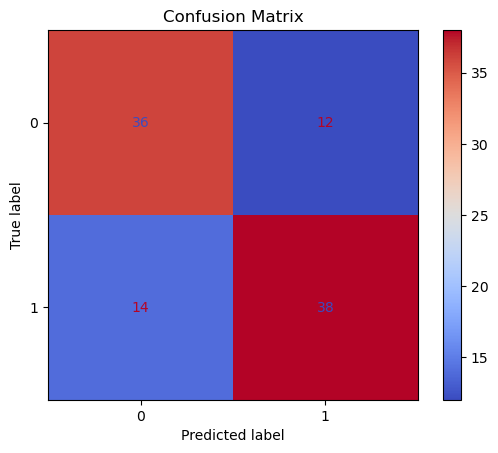

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73        48
           1       0.76      0.73      0.75        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



In [35]:
## poly karnel
svc= SVC(C=1,kernel='poly')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.76

In [36]:
## Rbf karnel
svc= SVC(C=1,kernel='rbf')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.77

In [37]:
## sigmoid kernal
svc= SVC(C=1,kernel='sigmoid',gamma=0.05)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

In [38]:
### gridsearch
from sklearn.model_selection import GridSearchCV

In [39]:
params ={'kernel':['linear','poly','rbf','sigmoid'] , 'C':range(1,11)}

In [40]:
grid_search = GridSearchCV(estimator=svc,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVC(C=1, gamma=0.05, kernel='sigmoid'),
             param_grid={'C': range(1, 11),
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [41]:
grid_search.best_params_,grid_search.best_score_

({'C': 1, 'kernel': 'rbf'}, np.float64(0.7275))